In [1]:
import sys
import os

# Get the current working directory
current_dir = '/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/'  #os.getcwd()
print(current_dir)

# Add the src directory to the Python path
src_path = os.path.join(os.path.dirname(current_dir), 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

import numpy as np
import matplotlib.pyplot as plt
import random

/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/


In [2]:
rat = 'r1'
mod = '3'
exp = 'OF'

general_results_working_directory = os.path.join(current_dir, 'results')
temporal_shift_results_path = general_results_working_directory + '/' + rat+mod + '/Temporal shift'
spatial_shift_results_path = general_results_working_directory + '/' + rat+mod + '/Spatial shift'
results_save_path = general_results_working_directory + '/' + rat+mod + '/Comparison'

In [3]:
# Loading spatial shift results
spatial_predictive_grid_cells = np.load(spatial_shift_results_path + '/predictive_grid_cells.npy')
spatial_predictive_grid_cells = np.argwhere(spatial_predictive_grid_cells)
spatial_best_d_values = np.load(spatial_shift_results_path + '/best_d.npy')
spatial_grid_scores = np.load(spatial_shift_results_path + '/grid_scores.npy')

In [4]:
# Loading temporal shift results
temporal_predictive_grid_cells = np.load(temporal_shift_results_path + '/predictive_grid_cells.npy')
temporal_predictive_grid_cells = np.argwhere(temporal_predictive_grid_cells)
temporal_best_delta_values = np.load(temporal_shift_results_path + '/best_delta.npy')
temporal_grid_scores = np.load(temporal_shift_results_path + '/grid_scores.npy')

In [5]:
# Identifying common predictive grid cells among shifts
common_predictive_grid_cells = np.intersect1d(temporal_predictive_grid_cells, spatial_predictive_grid_cells)
common_temporal_ratio = len(common_predictive_grid_cells) / len(temporal_predictive_grid_cells)
common_spatial_ratio = len(common_predictive_grid_cells) / len(spatial_predictive_grid_cells)

print('% temporal predictive grid cells that are spatial predictive grid cells: ' + str(common_temporal_ratio))
print('% spatial predictive grid cells that are temporal predictive grid cells: ' + str(common_spatial_ratio))

% temporal predictive grid cells that are spatial predictive grid cells: 0.625
% spatial predictive grid cells that are temporal predictive grid cells: 0.7692307692307693


In [6]:
fig_save_flag = False

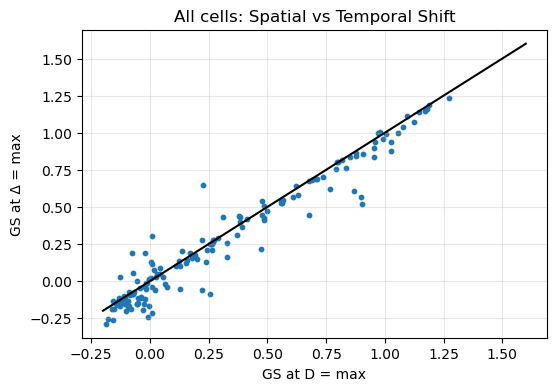

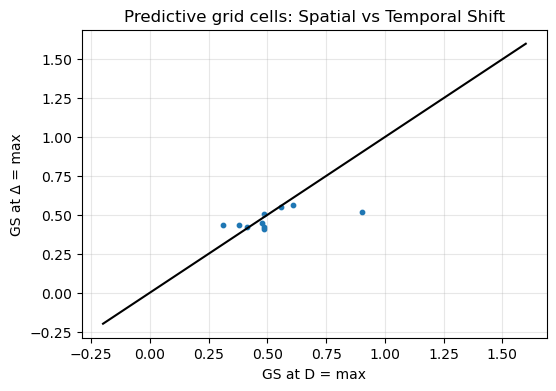

% predictive grid cells GS max spatial > GS max temporal: 0.6


In [7]:
# Comparing maximum grid scores
gsmax_spatial = np.max(spatial_grid_scores, axis=0)
gsmax_temporal = np.max(temporal_grid_scores, axis=0)

plt.figure(figsize=(6, 4))
plt.plot([-0.2, 1.6], [-0.2, 1.6], 'k-')
plt.scatter(gsmax_spatial, gsmax_temporal, s=10)
plt.xlabel("GS at D = max")
plt.ylabel("GS at Δ = max")
plt.title("All cells: Spatial vs Temporal Shift")
plt.grid(alpha=0.3)
if fig_save_flag:
    plt.savefig(results_save_path + '/all_cells_spatial_vs_temporal_shift_GS_max.png')
    plt.savefig(results_save_path + '/all_cells_spatial_vs_temporal_shift_GS_max.svg', format = 'svg')
plt.show()

plt.figure(figsize=(6, 4))
plt.plot([-0.2, 1.6], [-0.2, 1.6], 'k-')
plt.scatter(gsmax_spatial[common_predictive_grid_cells], gsmax_temporal[common_predictive_grid_cells], s=10)
plt.xlabel("GS at D = max")
plt.ylabel("GS at Δ = max")
plt.title("Predictive grid cells: Spatial vs Temporal Shift")
plt.grid(alpha=0.3)
if fig_save_flag:
    plt.savefig(results_save_path + '/predictive_grid_cells_spatial_vs_temporal_shift_GS_max.png')
    plt.savefig(results_save_path + '/predictive_grid_cells_spatial_vs_temporal_shift_GS_max.svg', format = 'svg')
plt.show()

print("% predictive grid cells GS max spatial > GS max temporal: " + str(len(np.argwhere(gsmax_spatial[common_predictive_grid_cells] > gsmax_temporal[common_predictive_grid_cells])) / len(common_predictive_grid_cells)))

In [19]:
rat = ['r1', 'r1', 'r1', 'r2', 'r2', 'r2', 'q', 'q', 's']
mod = ['1', '2', '3', '1', '2', '3', '1', '2', '1']
exp = 'OF'
n_recs = len(mod)
grid_cell_thresh = 0.5

delta_values = np.arange(-40, 40, 2)
temporal_idx0 = int(np.where(delta_values == 0)[0][0])
d_values = np.arange(-0.50, 0.52, 0.02)
spatial_idx0 = int(np.where(np.abs(d_values) < 1e-6)[0][0])

general_results_working_directory = os.path.join(current_dir, 'results')
results_save_path = general_results_working_directory + '/comparison'

temporal_gs_predictive_grid_cells = []
spatial_gs_predictive_grid_cells = []
percent_temporal_predictive_grid_cells = np.zeros(n_recs)
percent_spatial_predictive_grid_cells = np.zeros(n_recs)
n_cells = np.zeros(n_recs)
n_non_grid_cells = np.zeros(n_recs)
n_predictive_grid_cells_spatial = np.zeros(n_recs)
n_predictive_grid_cells_temporal = np.zeros(n_recs)

for ii in range(n_recs):
    temporal_shift_results_path = general_results_working_directory + '/' + rat[ii]+mod[ii] + '/Temporal shift'
    spatial_shift_results_path = general_results_working_directory + '/' + rat[ii]+mod[ii] + '/Spatial shift'

    # Loading spatial shift results
    spatial_predictive_grid_cells = np.load(spatial_shift_results_path + '/predictive_grid_cells.npy')
    spatial_predictive_grid_cells = np.argwhere(spatial_predictive_grid_cells)
    spatial_best_d_values = np.load(spatial_shift_results_path + '/best_d.npy')
    spatial_grid_scores = np.load(spatial_shift_results_path + '/grid_scores.npy')
    spatial_non_grid_cells = np.argwhere(spatial_grid_scores[spatial_idx0] < grid_cell_thresh)
    percent_spatial_predictive_grid_cells[ii] = len(spatial_predictive_grid_cells) / len(spatial_non_grid_cells)
    n_cells[ii] = len(spatial_grid_scores[spatial_idx0])
    n_non_grid_cells[ii] = len(spatial_non_grid_cells)
    n_predictive_grid_cells_spatial[ii] = len(spatial_predictive_grid_cells)

    # Loading temporal shift results
    temporal_predictive_grid_cells = np.load(temporal_shift_results_path + '/predictive_grid_cells.npy')
    temporal_predictive_grid_cells = np.argwhere(temporal_predictive_grid_cells)
    temporal_best_delta_values = np.load(temporal_shift_results_path + '/best_delta.npy')
    temporal_grid_scores = np.load(temporal_shift_results_path + '/grid_scores.npy')
    temporal_non_grid_cells = np.argwhere(temporal_grid_scores[temporal_idx0] < grid_cell_thresh)
    percent_temporal_predictive_grid_cells[ii] = len(temporal_predictive_grid_cells) / len(temporal_non_grid_cells)
    n_predictive_grid_cells_temporal[ii] = len(temporal_predictive_grid_cells)

    # Identifying common predictive grid cells among shifts
    common_predictive_grid_cells = np.intersect1d(temporal_predictive_grid_cells, spatial_predictive_grid_cells)
    common_temporal_ratio = len(common_predictive_grid_cells) / len(temporal_predictive_grid_cells)
    common_spatial_ratio = len(common_predictive_grid_cells) / len(spatial_predictive_grid_cells)

    # Saving max grid scores of common predictive grid cells
    gsmax_spatial = np.max(spatial_grid_scores, axis=0)
    spatial_gs_predictive_grid_cells.extend(gsmax_spatial[common_predictive_grid_cells].flatten())
    gsmax_temporal = np.max(temporal_grid_scores, axis=0)
    temporal_gs_predictive_grid_cells.extend(gsmax_temporal[common_predictive_grid_cells].flatten())


In [26]:
print(n_cells)
print(np.sum(n_cells))
print(np.sum(n_non_grid_cells))
print(np.sum(n_predictive_grid_cells_spatial))
print(np.sum(n_predictive_grid_cells_temporal))
print(np.median(percent_spatial_predictive_grid_cells))
print(np.median(percent_temporal_predictive_grid_cells))
print(percent_spatial_predictive_grid_cells)
print(percent_temporal_predictive_grid_cells)

[166. 168. 149. 189. 172. 183.  97.  66. 140.]
1330.0
564.0
108.0
117.0
0.27586206896551724
0.22413793103448276
[0.16129032 0.27586207 0.11711712 0.34042553 0.4        0.10884354
 0.34782609 0.44444444 0.02040816]
[0.14516129 0.22413793 0.14414414 0.40425532 0.475      0.10204082
 0.43478261 0.51851852 0.04081633]


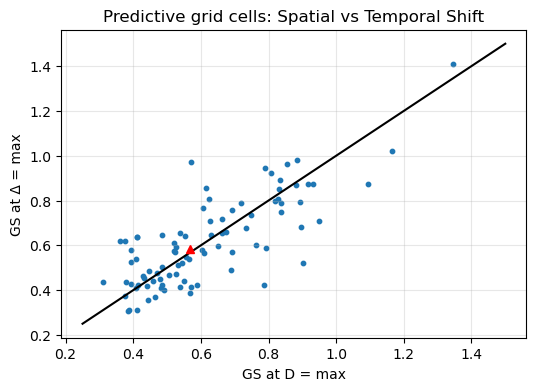

% predictive grid cells GS max spatial > GS max temporal: 0.5454545454545454
median spatial grid score: 0.5668661555164392
median temporal grid score: 0.5833644030332809


In [21]:
# Plotting
plt.figure(figsize=(6, 4))
plt.plot([0.25, 1.5], [0.25, 1.5], 'k-')
plt.scatter(spatial_gs_predictive_grid_cells, temporal_gs_predictive_grid_cells, s=10)
plt.plot(np.median(spatial_gs_predictive_grid_cells), np.median(temporal_gs_predictive_grid_cells), 'r^')
plt.xlabel("GS at D = max")
plt.ylabel("GS at Δ = max")
plt.title("Predictive grid cells: Spatial vs Temporal Shift")
plt.grid(alpha=0.3)
plt.savefig(results_save_path + '/predictive_grid_cells_spatial_vs_temporal_shift_GS_max.png')
plt.savefig(results_save_path + '/predictive_grid_cells_spatial_vs_temporal_shift_GS_max.svg', format = 'svg')
plt.show()

print("% predictive grid cells GS max spatial > GS max temporal: " + str(len(np.argwhere(np.array(spatial_gs_predictive_grid_cells) > np.array(temporal_gs_predictive_grid_cells)) )/ len(temporal_gs_predictive_grid_cells)))

print('median spatial grid score: ' + str(np.median(spatial_gs_predictive_grid_cells)))
print('median temporal grid score: ' + str(np.median(temporal_gs_predictive_grid_cells)))

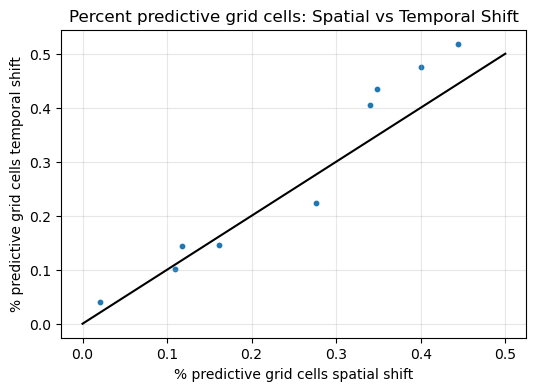

% recordings with more spatial predictive grid cells than temporal predictive grid cells: 0.3333333333333333
median % temporal predictive grid cells: 0.22413793103448276
range % temporal predictive grid cells: [0.04081632653061224, 0.5185185185185185]
median % spatial predictive grid cells: 0.27586206896551724
range % spatial predictive grid cells: [0.02040816326530612, 0.4444444444444444]


In [22]:
plt.figure(figsize=(6, 4))
plt.plot([0.0, 0.5], [0.0, 0.5], 'k-')
plt.scatter(percent_spatial_predictive_grid_cells, percent_temporal_predictive_grid_cells, s= 10)
plt.xlabel("% predictive grid cells spatial shift")
plt.ylabel("% predictive grid cells temporal shift")
plt.title("Percent predictive grid cells: Spatial vs Temporal Shift")
plt.grid(alpha=0.3)
plt.savefig(results_save_path + '/predictive_grid_cells_spatial_vs_temporal_shift_percent.png')
plt.savefig(results_save_path + '/predictive_grid_cells_spatial_vs_temporal_shift_percent.svg', format = 'svg')
plt.show()

print("% recordings with more spatial predictive grid cells than temporal predictive grid cells: " + str(len(np.argwhere(percent_spatial_predictive_grid_cells > percent_temporal_predictive_grid_cells)) / n_recs))

print("median % temporal predictive grid cells: " + str(np.median(percent_temporal_predictive_grid_cells)))
print("range % temporal predictive grid cells: [" + str(np.min(percent_temporal_predictive_grid_cells)) + ", " + str(np.max(percent_temporal_predictive_grid_cells)) + "]")

print("median % spatial predictive grid cells: " + str(np.median(percent_spatial_predictive_grid_cells)))
print("range % spatial predictive grid cells: [" + str(np.min(percent_spatial_predictive_grid_cells)) + ", " + str(np.max(percent_spatial_predictive_grid_cells)) + "]")